# Linear regression in diabetes dataset

Let's explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

In [3]:
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

Let's explore this variable by looking at the different attributes (keys) of `diabetes`. Note that the `load_diabetes` function does not return dataframes. It returns you a Python dictionary.

In [4]:
diabetes.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

#### The next step is to read the description of the dataset. 

Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable. Read the data description carefully to fully understand what each column represents.

*Hint: If your output is ill-formatted by displaying linebreaks as `\n`, it means you are not using the `print` function.*

In [5]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

#### Based on the data description, answer the following questions:

1. How many attributes are there in the data? What do they mean?

1. What is the relation between `diabetes['data']` and `diabetes['target']`?

1. How many records are there in the data?

In [7]:
df = pd.DataFrame(diabetes['data'], columns=diabetes['feature_names'])
df['target'] = diabetes['target']

# --- RESPUESTAS MEDIANTE CÓDIGO ---

# 1. Atributos y su significado
print(f"1. Número de atributos: {len(diabetes['feature_names'])}")
print(f"   Nombres: {diabetes['feature_names']}")

# 2. Relación (Correlación de cada atributo con el target)
# Calculamos la correlación de Pearson y extraemos la columna del target
correlaciones = df.corr()['target'].sort_values(ascending=False)
print(f"\n2. Relación (Correlación de Pearson con el Target):")
print(correlaciones.drop('target')) # Quitamos la correlación de target consigo mismo

# 3. Número de registros
print(f"\n3. Número de registros (filas): {df.shape[0]}")

1. Número de atributos: 10
   Nombres: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

2. Relación (Correlación de Pearson con el Target):
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64

3. Número de registros (filas): 442


#### Now explore what are contained in the *data* portion as well as the *target* portion of `diabetes`. 

Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). Inspect the shape of `data` and `target`. Confirm they are consistent with the data description.

In [8]:
# 1. Inspección de la forma (shape) de los datos
shape_data = diabetes['data'].shape
shape_target = diabetes['target'].shape

print(f"Forma de 'data' (X): {shape_data}")
print(f"Forma de 'target' (y): {shape_target}")

# 2. Confirmación con la descripción
# Según DESCR: 442 instancias y 10 atributos
print(f"\n¿Coincide el número de registros?: {shape_data[0] == 442}")
print(f"¿Coincide el número de atributos?: {shape_data[1] == 10}")

# 3. Vista rápida del contenido
print("\nPrimer registro de 'data':")
print(diabetes['data'][0])

print("\nPrimer valor de 'target':")
print(diabetes['target'][0])

Forma de 'data' (X): (442, 10)
Forma de 'target' (y): (442,)

¿Coincide el número de registros?: True
¿Coincide el número de atributos?: True

Primer registro de 'data':
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]

Primer valor de 'target':
151.0


## Building a regression model

The data have already been split to predictor (*data*) and response (*target*) variables. Given this information, we'll apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset.

#### In the cell below, import the `linear_model` class from `sklearn`. 

In [9]:
from sklearn import linear_model

#### Create a new instance of the linear regression model and assign the new instance to the variable `diabetes_model`.

In [10]:
diabetes_model = linear_model.LinearRegression()

#### Next, let's split the training and test data.

Define `diabetes_data_train`, `diabetes_target_train`, `diabetes_data_test`, and `diabetes_target_test`. Use the last 20 records for the test data and the rest for the training data.

In [11]:
# Los últimos 20 registros para el test data
diabetes_data_test = diabetes['data'][-20:]
diabetes_target_test = diabetes['target'][-20:]

# El resto para el training data
diabetes_data_train = diabetes['data'][:-20]
diabetes_target_train = diabetes['target'][:-20]

# Verificamos las dimensiones
print(f"Registros de entrenamiento: {len(diabetes_data_train)}")
print(f"Registros de prueba: {len(diabetes_data_test)}")

Registros de entrenamiento: 422
Registros de prueba: 20


Perform a brief exploratory analysis to investigate the conditions necessary for linear regression. This analysis will help you understand the distribution of the target variable and its correlations with other features.

Fit the training data and target to `diabetes_model`. Print the *intercept* and *coefficients* of the model.

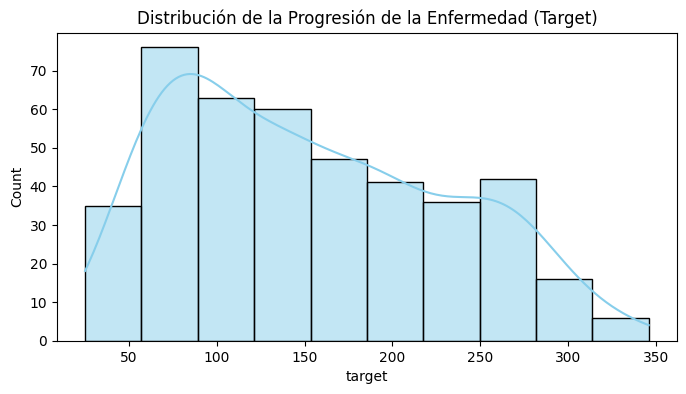

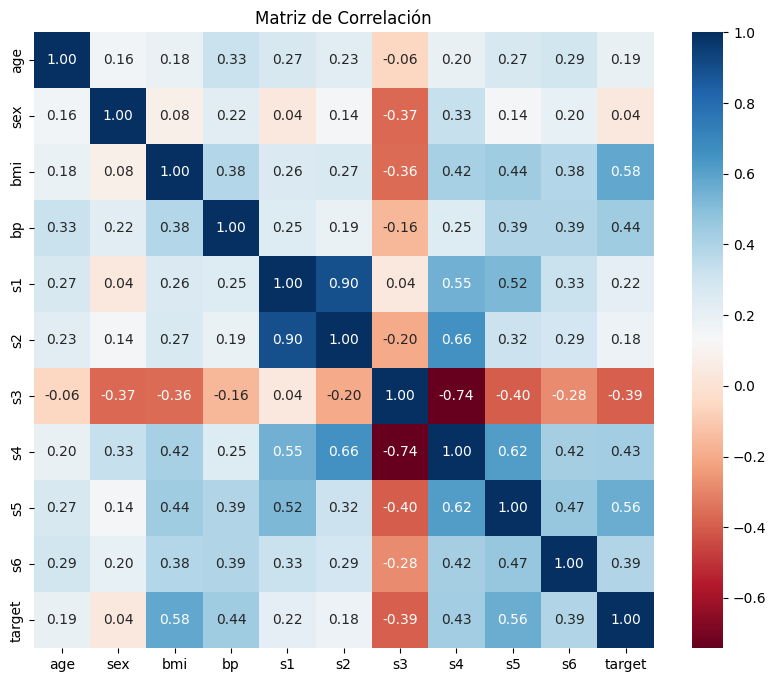

Intercepto (Beta 0): 152.7643

Coeficientes (Beta 1...n) por atributo:
age: 0.3061
sex: -237.6356
bmi: 510.5380
bp: 327.7299
s1: -814.1119
s2: 492.7996
s3: 102.8412
s4: 184.6035
s5: 743.5094
s6: 76.0966


In [12]:
# --- 1. Análisis Exploratorio Rápido ---
df_train = pd.DataFrame(diabetes_data_train, columns=diabetes['feature_names'])
df_train['target'] = diabetes_target_train

# Distribución del target (¿Es normal?)
plt.figure(figsize=(8, 4))
sns.histplot(df_train['target'], kde=True, color='skyblue')
plt.title('Distribución de la Progresión de la Enfermedad (Target)')
plt.show()

# Correlaciones (¿Hay relación lineal?)
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

# --- 2. Ajuste del Modelo (Fit) ---
diabetes_model.fit(diabetes_data_train, diabetes_target_train)

# --- 3. Intercepto y Coeficientes ---
print(f"Intercepto (Beta 0): {diabetes_model.intercept_:.4f}")
print("\nCoeficientes (Beta 1...n) por atributo:")
for name, coef in zip(diabetes['feature_names'], diabetes_model.coef_):
    print(f"{name}: {coef:.4f}")

#### Inspecting the results

From the outputs you should have seen:

- The intercept is a float number.
- The coefficients are an array containing 10 float numbers.

This is the linear regression model fitted to your training dataset.

#### Using your fitted linear regression model, predict the *y* of `diabetes_data_test`.

In [13]:
# Realizar las predicciones sobre los últimos 20 registros
diabetes_target_predicted = diabetes_model.predict(diabetes_data_test)

# Mostrar las primeras 5 predicciones para inspeccionar
print("Primeras 5 predicciones del conjunto de test:")
print(diabetes_target_predicted[:5])

# Comparar con los valores reales (opcional para inspección rápida)
print("\nPrimeros 5 valores reales correspondientes:")
print(diabetes_target_test[:5])

Primeras 5 predicciones del conjunto de test:
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301]

Primeros 5 valores reales correspondientes:
[233.  91. 111. 152. 120.]


#### Print your `diabetes_target_test` and compare with the prediction. 

In [15]:
# 1. Mostrar los arrays directamente
print("Valores Reales (diabetes_target_test):")
print(diabetes_target_test)

print("\nPredicciones (diabetes_target_predicted):")
print(diabetes_target_predicted)

# 2. Crear una tabla comparativa limpia para inspeccionar
df_comparacion = pd.DataFrame({
    'Real': diabetes_target_test,
    'Prediccion': diabetes_target_predicted
})

# Calculamos el error individual
df_comparacion['Error_Absoluto'] = abs(df_comparacion['Real'] - df_comparacion['Prediccion'])

print("\nTabla Comparativa de los últimos 20 registros:")
print(df_comparacion)

Valores Reales (diabetes_target_test):
[233.  91. 111. 152. 120.  67. 310.  94. 183.  66. 173.  72.  49.  64.
  48. 178. 104. 132. 220.  57.]

Predicciones (diabetes_target_predicted):
[197.61898486 155.44031962 172.88875144 111.53270645 164.79397301
 131.06765869 259.12441219 100.47873746 117.06005372 124.30261597
 218.36868146  61.19581944 132.24837933 120.33293546  52.54513009
 194.03746764 102.5756431  123.56778709 211.03465323  52.60221696]

Tabla Comparativa de los últimos 20 registros:
     Real  Prediccion  Error_Absoluto
0   233.0  197.618985       35.381015
1    91.0  155.440320       64.440320
2   111.0  172.888751       61.888751
3   152.0  111.532706       40.467294
4   120.0  164.793973       44.793973
5    67.0  131.067659       64.067659
6   310.0  259.124412       50.875588
7    94.0  100.478737        6.478737
8   183.0  117.060054       65.939946
9    66.0  124.302616       58.302616
10  173.0  218.368681       45.368681
11   72.0   61.195819       10.804181
12   49.

#### Is `diabetes_target_test` exactly the same as the model prediction? Use different error metrics

In [16]:
# 1. Calculamos la diferencia (errores)
errores = diabetes_target_test - diabetes_target_predicted

# 2. Cálculo de métricas manuales
mae = abs(errores).mean()
mse = (errores**2).mean()
rmse = mse**0.5
mape = (abs(errores) / diabetes_target_test).mean()

# 3. Mostrar resultados
print(f"¿Son iguales?: {all(diabetes_target_test == diabetes_target_predicted)}")
print(f"Métricas de Error:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4%}")

¿Son iguales?: False
Métricas de Error:
MAE:  36.6096
MSE:  2004.5187
RMSE: 44.7719
MAPE: 39.3088%


#### Iterate with a new model to assess if any improvements can be made compared to the previous one. Consider reducing the number of variables or using `StandardScaler` to enhance model performance.

In [19]:
# 1. Selección de variables con mayor impacto (BMI, S5, BP, S4)
columnas_top = ['bmi', 's5', 'bp', 's4']
df_data = pd.DataFrame(diabetes['data'], columns=diabetes['feature_names'])

# Filtramos las columnas y convertimos a valores para sklearn
X_reducido = df_data[columnas_top].values
y = diabetes['target']

# 2. Nueva división manual (últimos 20 para test)
X_train_red = X_reducido[:-20]
X_test_red = X_reducido[-20:]
y_train = y[:-20]
y_test = y[-20:]

# 3. Entrenar el modelo (Usando el prefijo correcto linear_model)
modelo_mejorado = linear_model.LinearRegression()
modelo_mejorado.fit(X_train_red, y_train)

# 4. Predicción y cálculo de errores
y_pred_red = modelo_mejorado.predict(X_test_red)
error_red = y_test - y_pred_red

mae_red = abs(error_red).mean()
rmse_red = (error_red**2).mean()**0.5

print(f"Métricas Modelo Reducido (Variables: {columnas_top}):")
print(f"MAE:  {mae_red:.4f}")
print(f"RMSE: {rmse_red:.4f}")

Métricas Modelo Reducido (Variables: ['bmi', 's5', 'bp', 's4']):
MAE:  38.6811
RMSE: 45.9174
